# PtychoLite tutorial 01

This notebook walks through a compact ptychography workflow in quantEM:
1. load a simulated 4D-STEM dataset,
2. run a standard pixelated reconstruction,
3. initialize and refine with a deep image prior (DIP) model.

The example uses the included `ducky` dataset so the full pipeline is runnable end-to-end.

Arthur McCray  
April 22, 2026

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from pathlib import Path

import torch 

import quantem as em
from quantem.core.datastructures import Dataset4dstem
from quantem.diffractive_imaging import PtychographyDatasetRaster, PtychoLite, PtychoLiteDIP
from quantem.core import config

GPU_ID = 0
print(f"quantEM version: {em.__version__}")
# Select the default compute device for this session.
if torch.cuda.is_available():
    print(f"There are {torch.cuda.device_count()} GPUs available")
    config.set_device(GPU_ID)
    print(f"Using device {config.get('device')} | {torch.cuda.get_device_name(config.get('device'))}")
else: 
    if torch.backends.mps.is_available():
        print("No GPUs available, using MPS")
        config.set_device("mps")
    else:
        print("No GPUs available, using CPU")
        config.set_device("cpu")

/home/amccray/code/quantem/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


quantEM version: 0.1.8
There are 4 GPUs available
Using device cuda:2 | NVIDIA RTX PRO 6000 Blackwell Server Edition


## Load the simulated dataset
The `ducky` dataset used here is bundled with the repository.
It contains diffraction patterns on a raster scan grid and is convenient for quick iteration.

In this section we load the data, print its metadata, and define the probe settings reused throughout the notebook.
If you want to regenerate the dataset, see `simulation_notebooks/ducky-dataset.ipynb`.

In [3]:
filepath = Path("../../data/ducky_251105_20mrad_500A-df_4A-step_5e+04-dose_clean.zip")
dset: Dataset4dstem = em.io.load(filepath)
print(dset)

PROBE_ENERGY = 80e3 # eV, accelerating voltage
PROBE_SEMIANGLE = 20 # mrad, probe convergence semiangle
PROBE_DEFOCUS = 500 # A, probe defocus

quantem Dataset named 'ducky_251105_clean'
  shape: (37, 37, 200, 200)
  dtype: float32
  device: cpu
  origin: [0. 0. 0. 0.]
  sampling: [4.    4.    0.025 0.025]
  units: ['A', 'A', 'A^-1', 'A^-1']
  signal units: 'arb. units'


Calculated best fit rotation = 0 degrees.


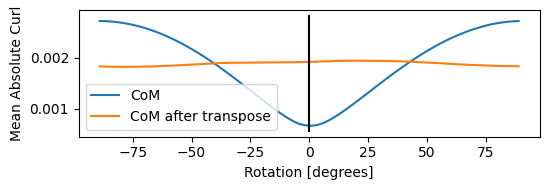

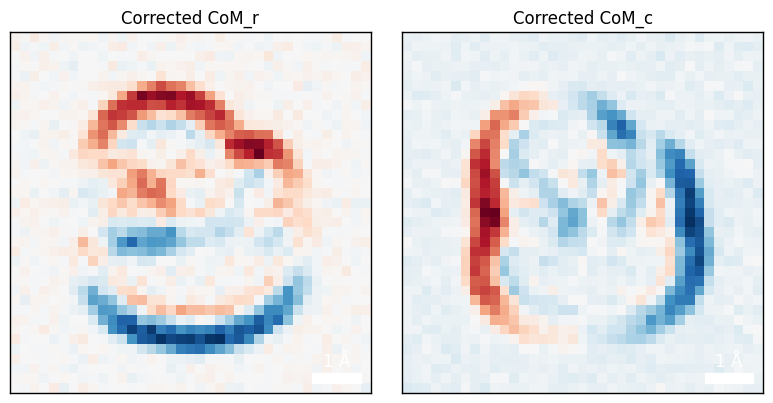

Normalizing intensities: 100%|██████████| 1369/1369 [00:01<00:00, 855.01probe position/s]


In [4]:
pdset = PtychographyDatasetRaster.from_dataset4dstem(dset)

pdset.preprocess(
    com_fit_function="constant",
    plot_rotation=True,
    plot_com=True,
)

In [5]:
ptycho_pix = PtychoLite.from_dataset(
    dset=pdset,
    num_slices=1,
    num_probes=1,
    obj_type="pure_phase",
    energy=PROBE_ENERGY,
    defocus=PROBE_DEFOCUS,
    semiangle_cutoff=PROBE_SEMIANGLE,
    obj_padding_px=(32,32),
)

Iter 50/50, Loss: 4.566e+00: 100%|██████████| 50/50 [00:03<00:00, 15.75it/s]


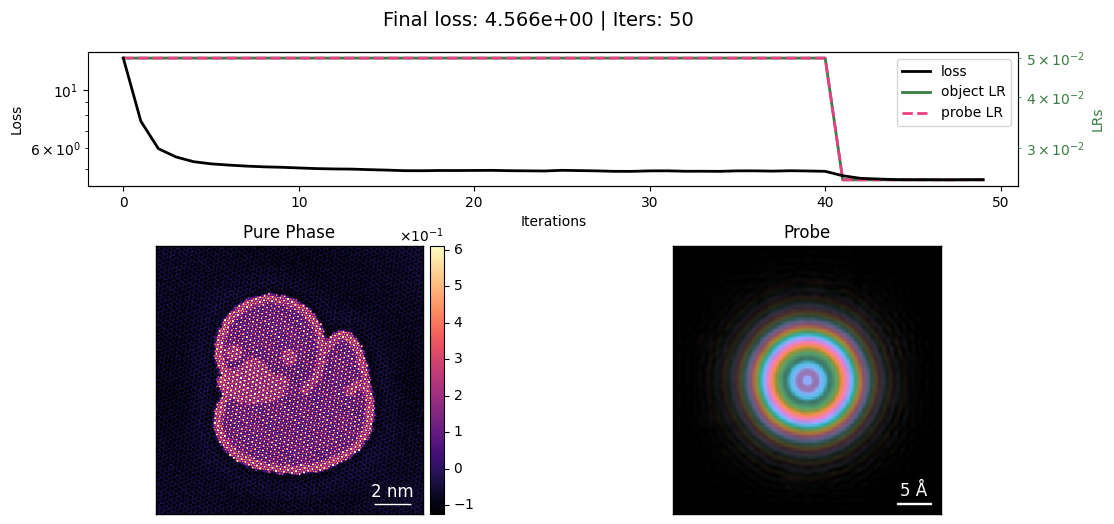

In [6]:
ptycho_pix.reconstruct(
    num_iters=50,
    reset=True,
    lr_obj=5e-2,
    lr_probe=5e-2,
    device="gpu", # Use the default GPU selected above via config.set_device().
    # Equivalent to device=config.get("device").
    # You can also pass an integer (for example, device=3) to force a specific GPU.
    batch_size=125,
    scheduler_type="plateau",
).visualize()

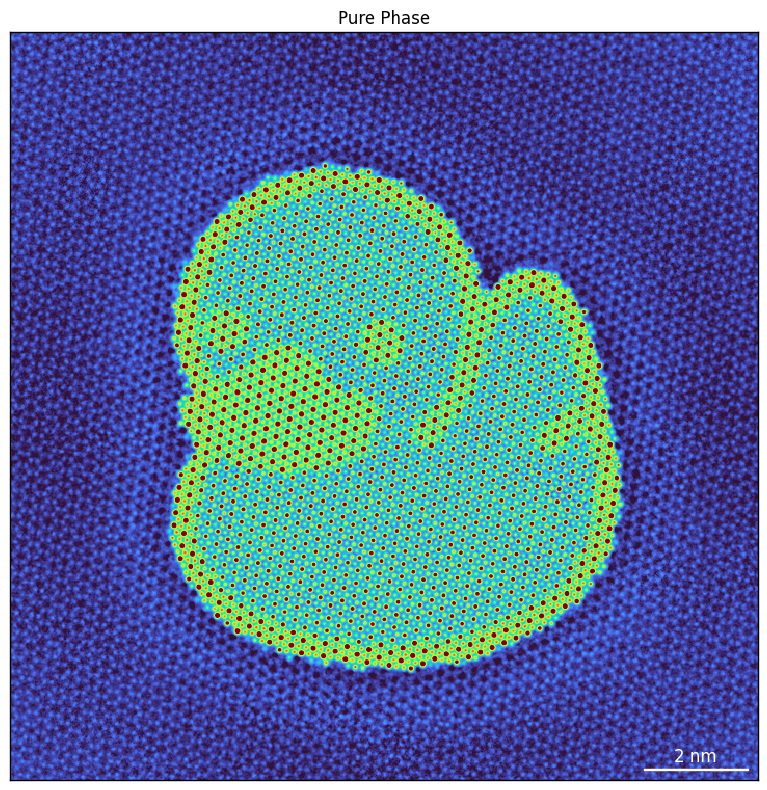

In [7]:
ptycho_pix.show_obj(axsize=(8,8), cmap='turbo')

Iter 1/200, Loss: 4.565e+00:   0%|          | 0/200 [00:00<?, ?it/s]

Iter 200/200, Loss: 4.405e+00: 100%|██████████| 200/200 [00:11<00:00, 17.06it/s]


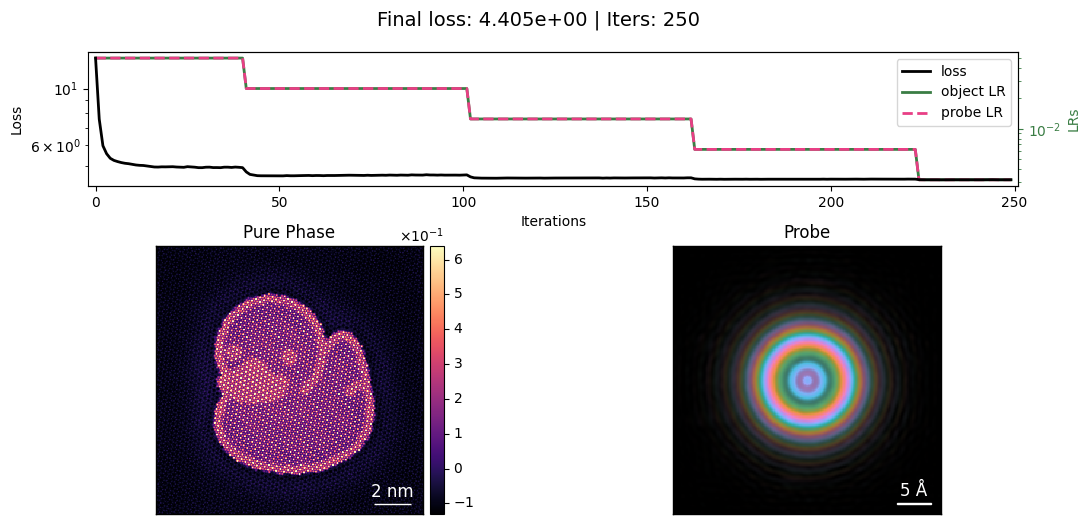

In [8]:
# `reset=False` (default) continues optimization from the current model state.
ptycho_pix.reconstruct(num_iters=200).visualize()

## Deep image prior (DIP)
The DIP workflow replaces direct pixel-wise optimization of the object and probe with a neural parameterization.
A common pattern is to start from a short pixelated reconstruction, then let the DIP models refine from that initialization.

Iter 5/5, Loss: 5.344e+00: 100%|██████████| 5/5 [00:00<00:00, 17.07it/s]


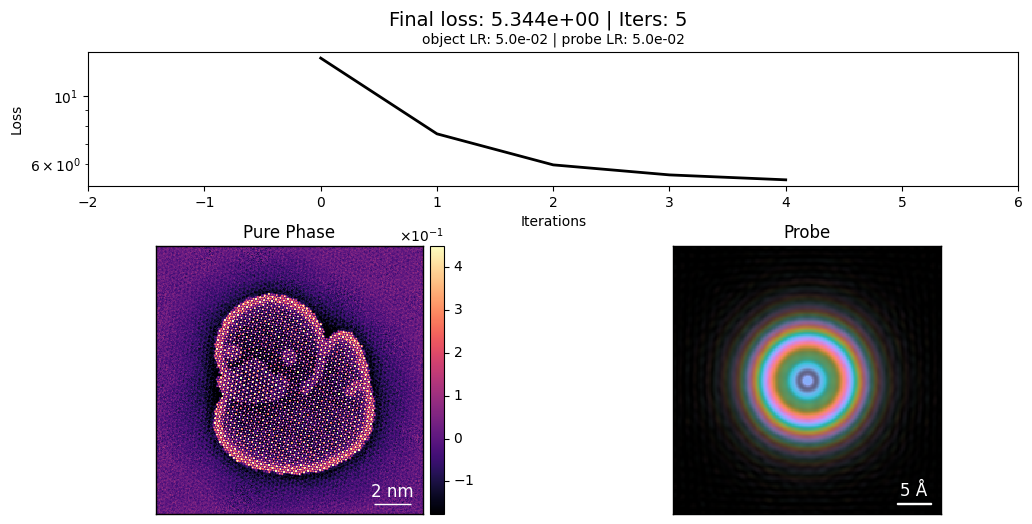

In [9]:
# Make a copy so we can run only a short pixelated reconstruction first.
# Starting DIP from a partially converged state makes the comparison more instructive.
ptycho_pix2 = PtychoLite.from_ptychography(
    ptycho=ptycho_pix,
) # Copying still has overhead in the current implementation.
ptycho_pix2.reconstruct(num_iters=5, device='gpu', lr_obj=5e-2, lr_probe=5e-2).visualize()

  0%|          | 0/50 [00:00<?, ?it/s]

Iter 50/50, Loss: 1.637e-03, : 100%|██████████| 50/50 [00:01<00:00, 47.73it/s]


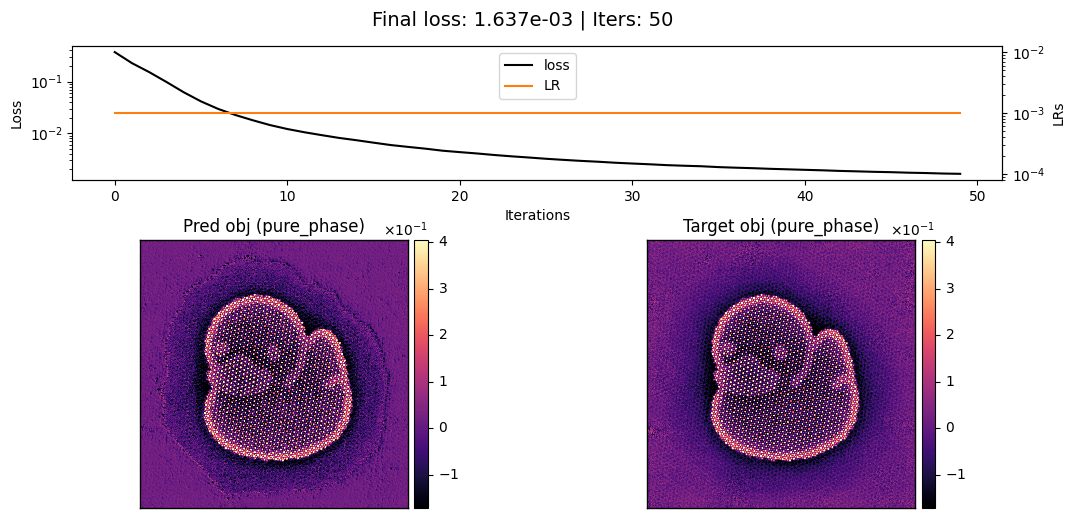

Iter 50/50, Loss: 1.660e-02, : 100%|██████████| 50/50 [00:00<00:00, 54.14it/s]


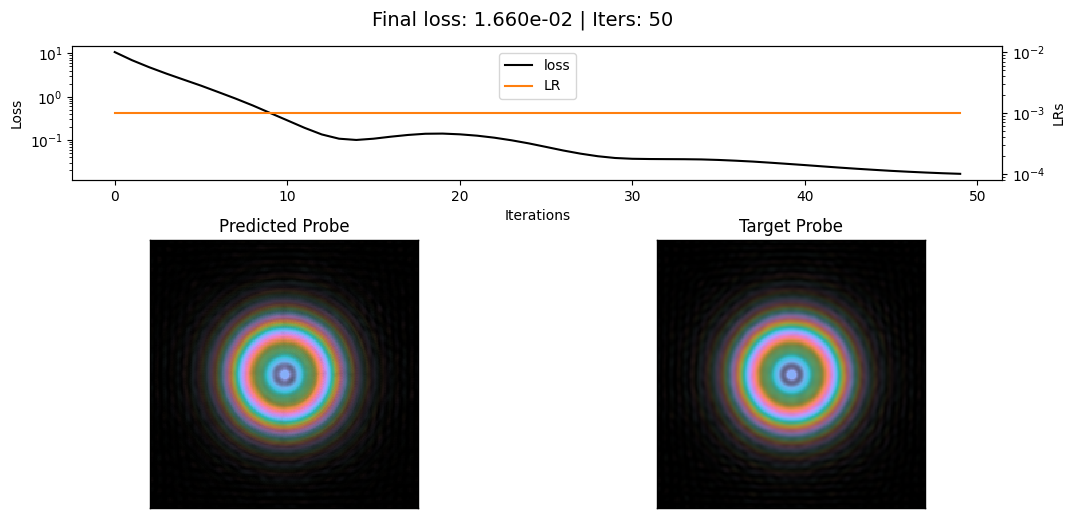

In [10]:
# Initialize DIP from the pixelated solution, then run a short pretraining phase.
ptycho_dip = PtychoLiteDIP.from_ptycholite(
    ptycholite=ptycho_pix2,
    pretrain_iters=50,
    device='gpu', 
)

  0%|          | 0/15 [00:00<?, ?it/s]

Iter 15/15, Loss: 4.746e+00: 100%|██████████| 15/15 [00:07<00:00,  2.13it/s]


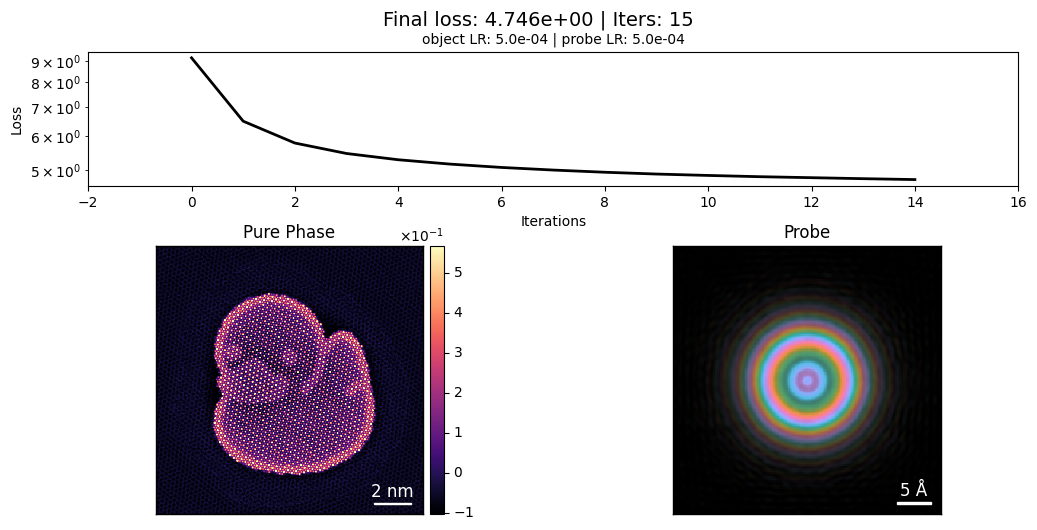

In [11]:
ptycho_dip.reconstruct(
    num_iters=15, 
    reset=True, 
    lr_obj=5e-4,
    lr_probe=5e-4,
    scheduler_type="plateau", # Other options: `exponential`, `cyclic`, `none` (default).
    batch_size=125,
).visualize()

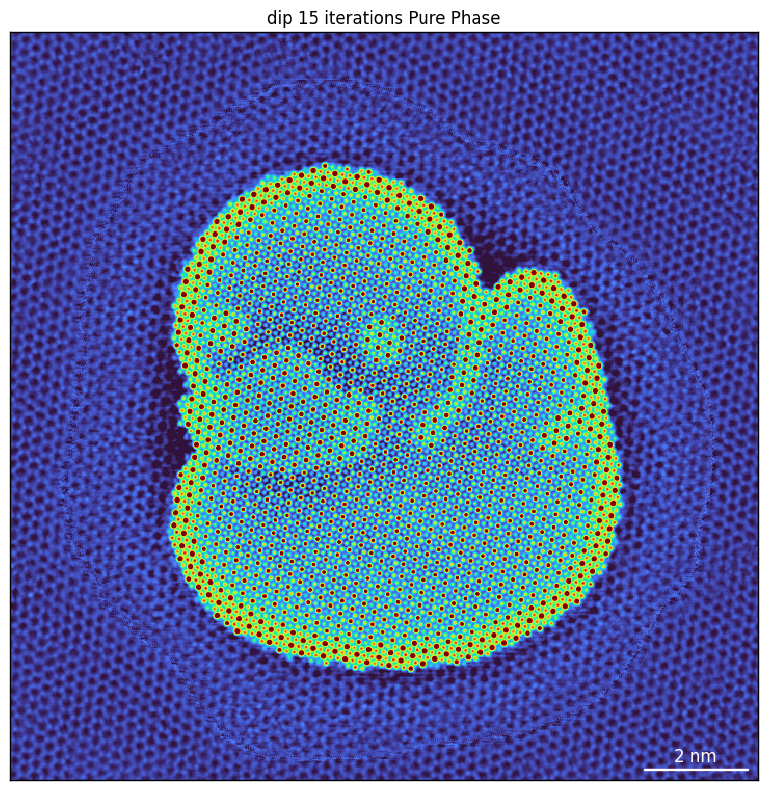

In [12]:
ptycho_dip.show_obj(axsize=(8,8), cmap='turbo', title=f'dip {ptycho_dip.num_iters} iterations')

  0%|          | 0/15 [00:00<?, ?it/s]

Iter 15/15, Loss: 4.620e+00: 100%|██████████| 15/15 [00:07<00:00,  2.11it/s]


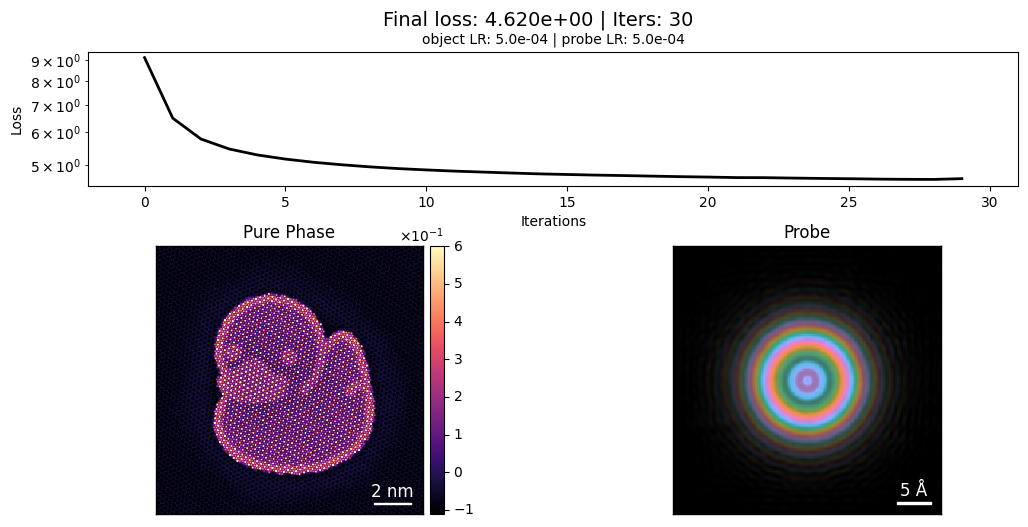

In [13]:
ptycho_dip.reconstruct(num_iters=15).visualize()

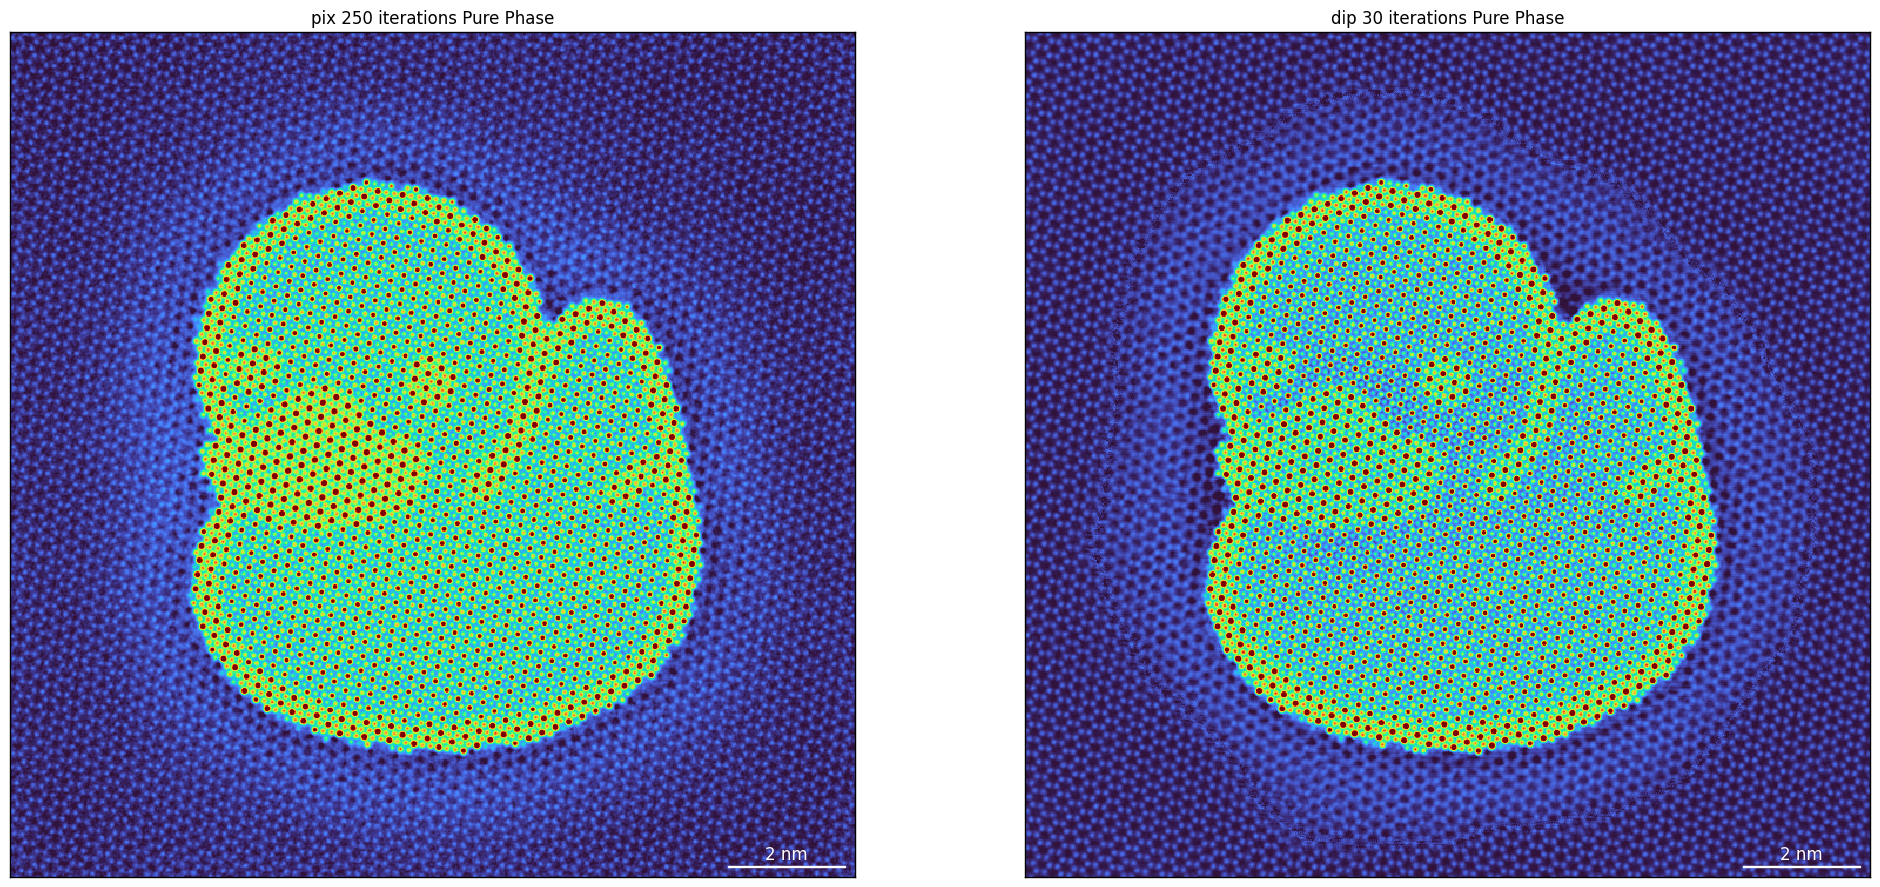

In [18]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(ncols=2, figsize=(24,12))
ptycho_pix.show_obj(figax=(fig,ax[0]), cmap='turbo', title=f'pix {ptycho_pix.num_iters} iterations')
ptycho_dip.show_obj(figax=(fig,ax[1]), cmap='turbo', title=f'dip {ptycho_dip.num_iters} iterations')
plt.show()

## Saving and loading
You can serialize the current reconstruction state to disk and resume later.
This is useful for long runs or when moving between sessions.

In [15]:
savedir = Path("../../outputs/diffractive_imaging")
savedir.mkdir(exist_ok=True) 
ptycho_dip.save(savedir / "ptycholite_dip.zip", mode='o')

Saving ptychography object to /home/amccray/code/quantem-tutorials/outputs/diffractive_imaging/ptycholite_dip.zip


In [16]:
ptycho_dip2 = PtychoLite.from_file(savedir / "ptycholite_dip.zip", dset = pdset)

Iter 10/10, Loss: 4.548e+00: 100%|██████████| 10/10 [00:04<00:00,  2.01it/s]


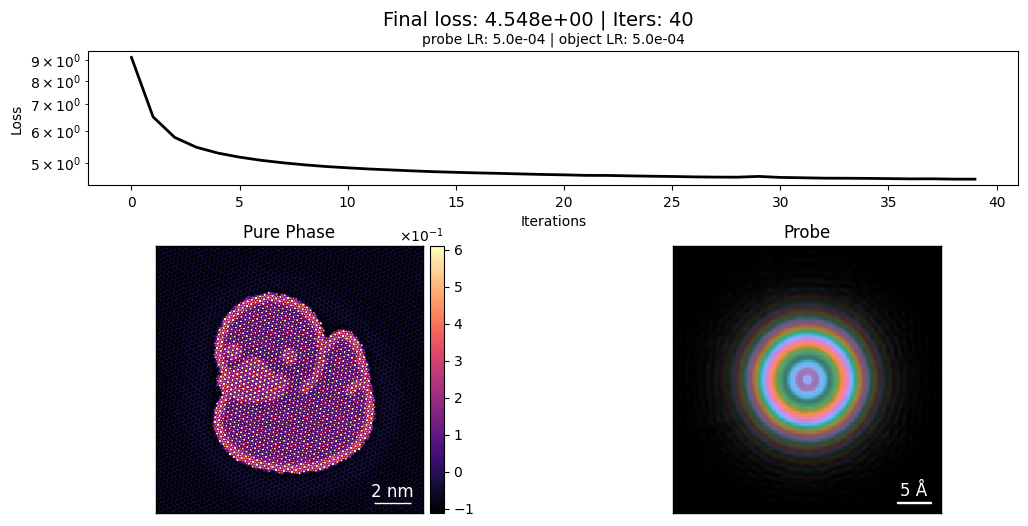

In [17]:
ptycho_dip2.reconstruct(
    num_iters=10,
    device='gpu',
).visualize()

-- End notebook --